1. LOAD DATA

In [9]:
import pickle

file_path = "../data/raw/WESAD/S2/S2.pkl"   # change to your file location

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())

dict_keys(['signal', 'label', 'subject'])


2. fILTER

In [10]:
from scipy.signal import butter, filtfilt
import numpy as np

# Load BVP
bvp = data['signal']['wrist']['BVP'].flatten()

# Sampling frequency
fs = 64

# Bandpass range
lowcut = 0.7
highcut = 5

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

bvp_filtered = filtfilt(b, a, bvp)

print("Raw BVP shape:", bvp.shape)
print("Filtered BVP shape:", bvp_filtered.shape)

Raw BVP shape: (389056,)
Filtered BVP shape: (389056,)


3. Compare Raw vs Filtered

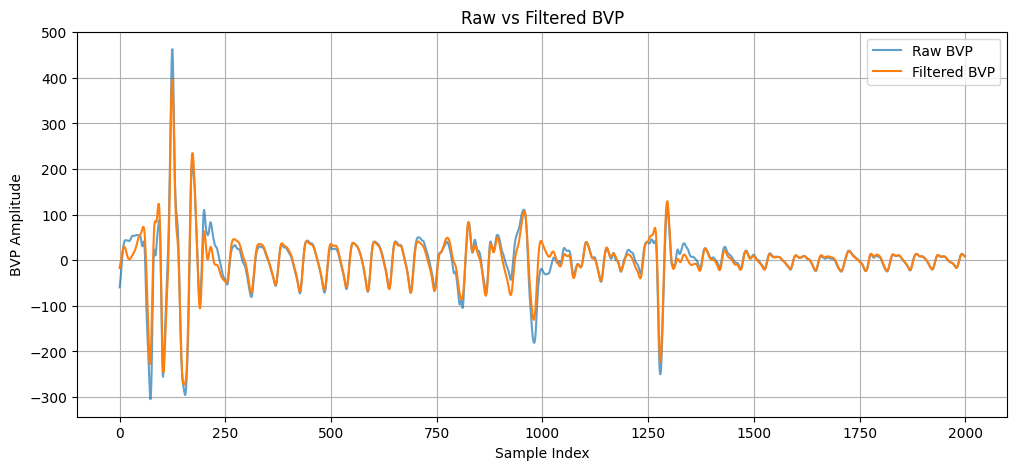

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

samples = 2000

plt.plot(bvp[:samples], label='Raw BVP', alpha=0.7)
plt.plot(bvp_filtered[:samples], label='Filtered BVP')

plt.title('Raw vs Filtered BVP')
plt.xlabel('Sample Index')
plt.ylabel('BVP Amplitude')
plt.legend()
plt.grid(True)

plt.show()

4.Quantitative Evaluation

In [12]:
import numpy as np
import pandas as pd

raw_z = np.abs((bvp - np.mean(bvp))/np.std(bvp))
filtered_z = np.abs((bvp_filtered - np.mean(bvp_filtered))/np.std(bvp_filtered))

raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)

noise_raw = np.std(np.diff(bvp))
noise_filtered = np.std(np.diff(bvp_filtered))

results = pd.DataFrame({
    "Metric":["Mean","Std","Spikes (>3σ)","Noise Estimate"],
    "Raw":[
        np.mean(bvp),
        np.std(bvp),
        raw_spikes,
        noise_raw
    ],
    "Filtered":[
        np.mean(bvp_filtered),
        np.std(bvp_filtered),
        filtered_spikes,
        noise_filtered
    ]
})

print(results)

           Metric           Raw      Filtered
0            Mean     -0.000427      0.001310
1             Std     75.871236     65.540683
2    Spikes (>3σ)  10644.000000  10529.000000
3  Noise Estimate     11.943682     10.824151


In [13]:
print(np.min(bvp))
print(np.max(bvp))

print(np.min(bvp_filtered))
print(np.max(bvp_filtered))

-873.67
988.08
-668.0084843273672
818.2277241362794


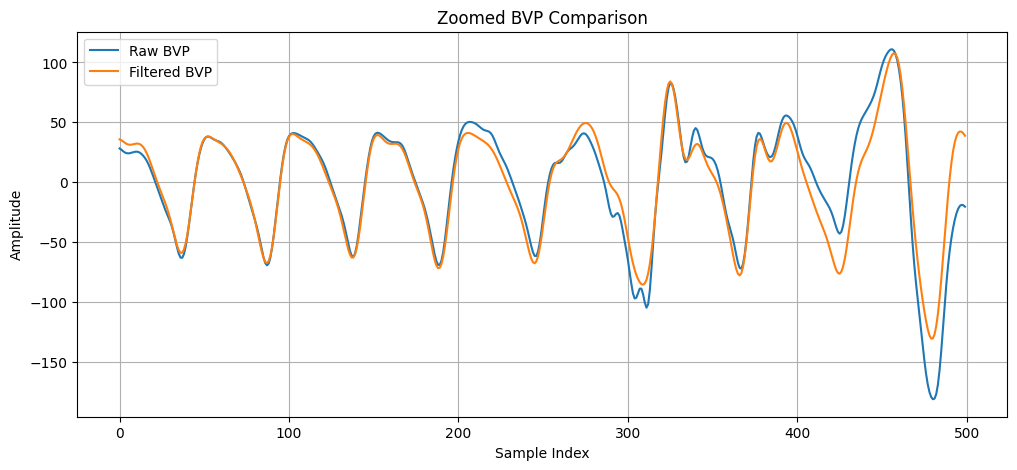

In [14]:
plt.figure(figsize=(12,5))

start = 500
end = 1000

plt.plot(bvp[start:end], label='Raw BVP')
plt.plot(bvp_filtered[start:end], label='Filtered BVP')

plt.title('Zoomed BVP Comparison')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()